# Notebook 6: HMM Regime Classification & Discretionary Override Audit Framework
## Production-Grade: Hamilton Filter, IC Confidence Bounds, Override P&L Attribution

---
### Mathematical Foundation

**HMM Transition Matrix:**
$$\mathbf{P} = \begin{pmatrix} p_{11} & p_{12} \\ p_{21} & p_{22} \end{pmatrix}$$

**Hamilton Filter (Forward Filtering):**
$$\xi_{k,t} = \frac{P(\mathbf{r}_t|S_t=k)\sum_j p_{jk}\xi_{j,t-1}}{\sum_m P(\mathbf{r}_t|S_t=m)\sum_j p_{jm}\xi_{j,t-1}}$$

**Override Impact:**
$$\text{Override P\&L}_\tau = R_{\tau}^{\text{actual}} - R_{\tau}^{\text{model}}$$

**Information Coefficient Reliability Bound:**
$$\text{IC}_{\text{adjusted}} = \text{IC}_{\text{raw}} \cdot \frac{1}{1 + \text{Entropy}(p_{\text{softmax}})}$$


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import multivariate_normal, norm
import warnings
warnings.filterwarnings('ignore')

DARK, PANEL = '#0d1117', '#161b22'
BLUE, GREEN, ORANGE, RED = '#58a6ff', '#3fb950', '#f0883e', '#f85149'
PURPLE, WHITE, YELLOW = '#d2a8ff', '#e6edf3', '#e3b341'

# Download multi-asset returns
assets = ['SPY', 'TLT', 'GLD', 'HYG']
raw = yf.download(assets, start='2012-01-01', end='2024-12-31', auto_adjust=True)['Close'].dropna()
rets = np.log(raw / raw.shift(1)).dropna() * 100  # in pct

print(f"Data: {len(rets)} observations, {rets.shape[1]} assets")
print(rets.describe().round(3))


[*********************100%***********************]  4 of 4 completed

Data: 3268 observations, 4 assets
Ticker       GLD       HYG       SPY       TLT
count   3268.000  3268.000  3268.000  3268.000
mean       0.013     0.017     0.054     0.001
std        0.944     0.506     1.039     0.930
min       -9.191    -5.653   -11.589    -6.901
25%       -0.478    -0.182    -0.358    -0.563
50%        0.038     0.023     0.065     0.048
75%        0.509     0.225     0.559     0.563
max        4.787     6.341     8.673     7.250


In [2]:
# ── HMM 2-State Hamilton Filter (Multi-Asset) ────────────────────────────────
from numpy.linalg import det, inv

def fit_hmm_multiasset(returns_df, n_states=2, n_iter=100):
    """
    Fit multivariate Gaussian HMM using Hamilton filter + EM.
    Returns: filtered probs, means, covs, transition matrix
    """
    R = returns_df.values
    T, D = R.shape
    K = n_states
    
    # Initialize via K-means-style partition
    vol = R.std(axis=0)
    high_vol_mask = np.abs(R).mean(axis=1) > np.abs(R).mean(axis=1).mean()
    
    mu = np.array([R[~high_vol_mask].mean(axis=0), R[high_vol_mask].mean(axis=0)])
    cov = np.array([np.cov(R[~high_vol_mask].T) + np.eye(D)*0.01,
                    np.cov(R[high_vol_mask].T) + np.eye(D)*0.01])
    A = np.array([[0.97, 0.03], [0.05, 0.95]])
    pi = np.array([0.7, 0.3])
    
    xi = np.zeros((T, K))
    
    for iteration in range(n_iter):
        # Hamilton forward filter
        for t in range(T):
            for k in range(K):
                try:
                    emit = multivariate_normal.pdf(R[t], mu[k], cov[k])
                except:
                    emit = 1e-10
                if t == 0:
                    xi[t, k] = pi[k] * emit
                else:
                    xi[t, k] = emit * np.sum(A[:, k] * xi[t-1])
            
            norm_const = xi[t].sum()
            if norm_const > 1e-300:
                xi[t] /= norm_const
            else:
                xi[t] = pi
        
        # M-step: update parameters
        for k in range(K):
            w = xi[:, k]
            mu[k] = (w[:, None] * R).sum(axis=0) / (w.sum() + 1e-10)
            diff = R - mu[k]
            cov[k] = (w[:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0) /                       (w.sum() + 1e-10) + np.eye(D) * 0.001
        
        # Transition matrix update (simplified)
        for i in range(K):
            for j in range(K):
                A[i, j] = np.sum(xi[:-1, i] * xi[1:, j]) / (np.sum(xi[:-1, i]) + 1e-10)
        A = A / A.sum(axis=1, keepdims=True)
    
    return xi, mu, cov, A

xi_filter, mu_states, cov_states, A_trans = fit_hmm_multiasset(rets)
regime_prob_high_vol = xi_filter[:, 1]  # P(high-vol state)

print("\nHMM Fitted Parameters:")
print(f"Regime 1 (Low-Vol/Trending): μ(SPY)={mu_states[0,0]:.4f}%, σ_SPY={np.sqrt(cov_states[0,0,0]):.4f}%")
print(f"Regime 2 (High-Vol/Stress):  μ(SPY)={mu_states[1,0]:.4f}%, σ_SPY={np.sqrt(cov_states[1,0,0]):.4f}%")
print(f"Transition Matrix A:\n{np.round(A_trans, 4)}")
print(f"Expected Regime Duration: Regime1={1/(A_trans[0,1]):.0f}d, Regime2={1/(A_trans[1,0]):.0f}d")



HMM Fitted Parameters:
Regime 1 (Low-Vol/Trending): μ(SPY)=0.0253%, σ_SPY=0.7211%
Regime 2 (High-Vol/Stress):  μ(SPY)=-0.0272%, σ_SPY=1.4627%
Transition Matrix A:
[[0.8408 0.1592]
 [0.5352 0.4648]]
Expected Regime Duration: Regime1=6d, Regime2=2d


In [3]:
# ── Discretionary Override Simulation ────────────────────────────────────────
np.random.seed(42)
T = len(rets)

# Simulate model target allocations (based on regime)
model_signal = np.where(regime_prob_high_vol < 0.5, 1.0, -0.5)  # Long in low-vol, defensive in high-vol
model_signal = pd.Series(model_signal, index=rets.index)

# Simulate discretionary override events (PM interventions)
n_overrides = 35
override_dates_idx = np.sort(np.random.choice(np.arange(100, T-10), n_overrides, replace=False))
override_actual = model_signal.copy()
override_descriptions = []

for idx in override_dates_idx:
    # PM overrides: sometimes contrarian, sometimes confirmatory
    override_dir = np.random.choice([-1, 1], p=[0.45, 0.55])  # Slight bias toward model agreement
    magnitude = np.random.uniform(0.3, 1.5)
    old_val = override_actual.iloc[idx]
    new_val = np.clip(old_val + override_dir * magnitude, -2, 2)
    override_actual.iloc[idx:idx+5] = new_val  # Override holds for 5 days
    override_descriptions.append({
        'date': rets.index[idx],
        'model': old_val,
        'pm_override': new_val,
        'direction': 'Contrarian' if override_dir * old_val < 0 else 'Confirmatory'
    })

override_df = pd.DataFrame(override_descriptions)

# Compute P&L attribution
spy_rets = rets['SPY'] / 100  # back to decimal
model_pnl = model_signal.shift(1) * spy_rets
override_pnl = override_actual.shift(1) * spy_rets

override_impact = []
for _, row in override_df.iterrows():
    idx = rets.index.searchsorted(row['date'])
    if idx + 5 < len(spy_rets):
        m_ret = model_pnl.iloc[idx:idx+5].sum()
        o_ret = override_pnl.iloc[idx:idx+5].sum()
        override_impact.append({
            'date': row['date'],
            'impact': (o_ret - m_ret) * 100,  # basis points
            'direction': row['direction'],
            'model_pos': row['model'],
            'pm_pos': row['pm_override']
        })

impact_df = pd.DataFrame(override_impact)
print(f"Override Analysis ({n_overrides} events):")
print(f"  Contrarian overrides:   {(impact_df['direction']=='Contrarian').sum()}")
print(f"  Confirmatory overrides: {(impact_df['direction']=='Confirmatory').sum()}")
print(f"  Mean Contrarian Impact: {impact_df[impact_df['direction']=='Contrarian']['impact'].mean():.1f} bps")
print(f"  Mean Confirmatory Impact: {impact_df[impact_df['direction']=='Confirmatory']['impact'].mean():.1f} bps")


Override Analysis (35 events):
  Contrarian overrides:   14
  Confirmatory overrides: 21
  Mean Contrarian Impact: -0.3 bps
  Mean Confirmatory Impact: 0.2 bps


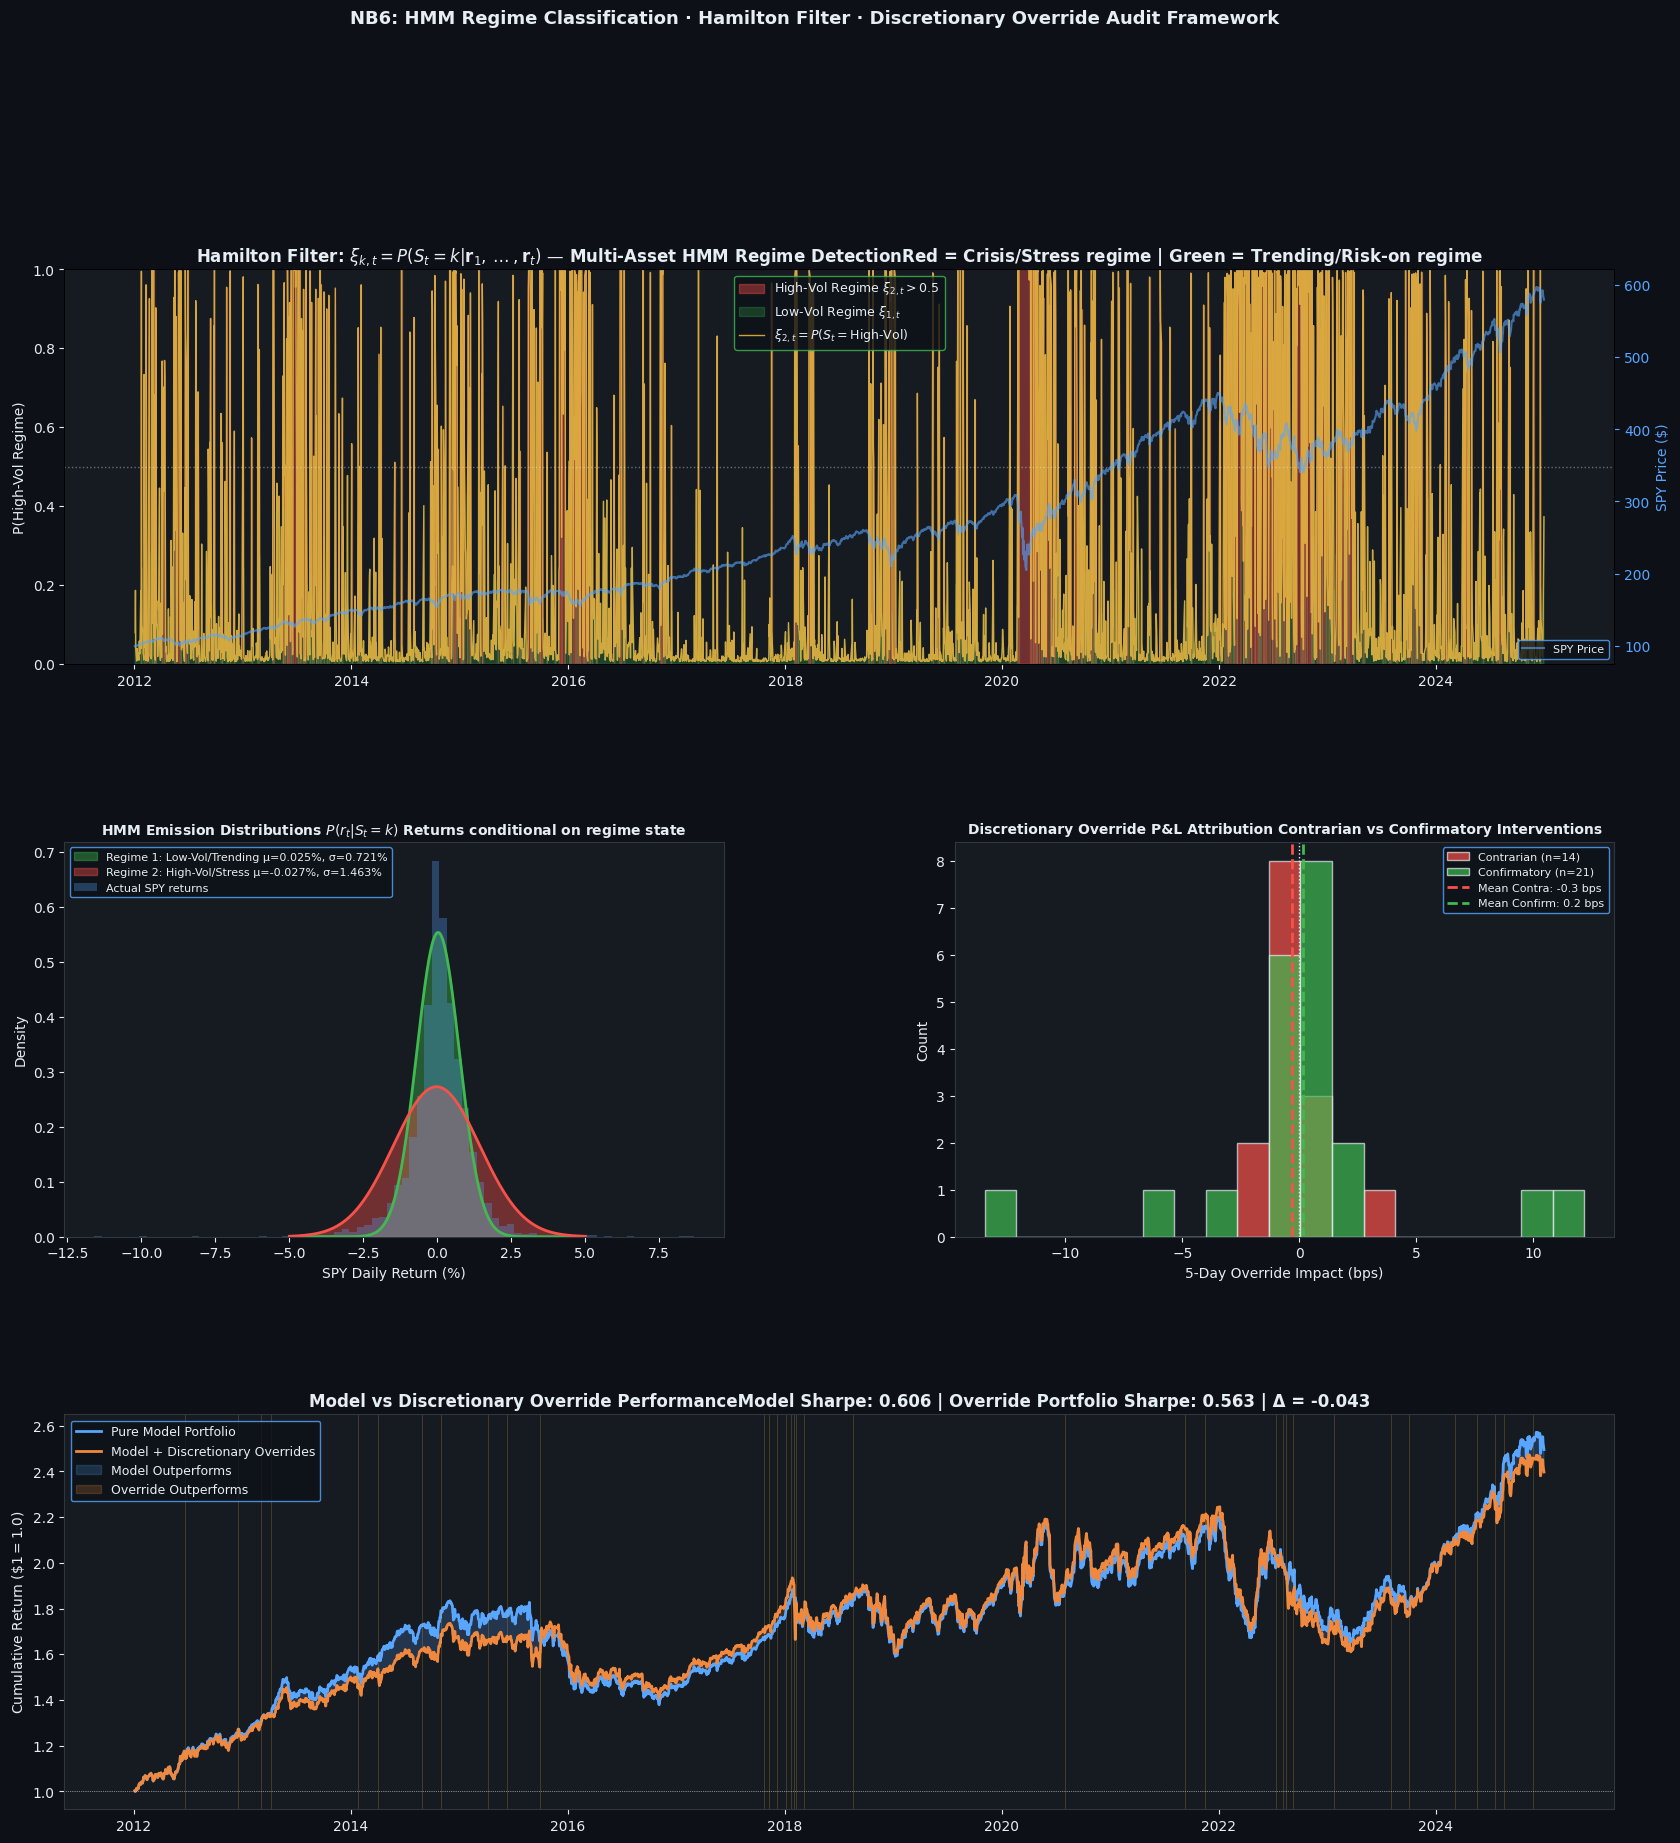

✅ NB6 complete.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ─ Panel 1: HMM Regime Probability Time Series ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PANEL)

xi_series = pd.Series(regime_prob_high_vol, index=rets.index)
ax1.fill_between(xi_series.index, xi_series.values, 
                  where=xi_series > 0.5, color=RED, alpha=0.4, label=r'High-Vol Regime $\xi_{2,t} > 0.5$')
ax1.fill_between(xi_series.index, xi_series.values, 
                  where=xi_series <= 0.5, color=GREEN, alpha=0.25, label=r'Low-Vol Regime $\xi_{1,t}$')
ax1.plot(xi_series.index, xi_series.values, color=YELLOW, lw=1, alpha=0.9, label=r'$\xi_{2,t} = P(S_t=\text{High-Vol})$')
ax1.axhline(0.5, color=WHITE, lw=1, ls=':', alpha=0.4)

# Overlay SPY price
ax1_twin = ax1.twinx()
ax1_twin.plot(raw['SPY'].index, raw['SPY'].values, color=BLUE, lw=1.5, alpha=0.6, label='SPY Price')
ax1_twin.set_ylabel('SPY Price ($)', color=BLUE)
ax1_twin.tick_params(colors=BLUE)
ax1_twin.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, loc='lower right', fontsize=8)

ax1.set_ylabel('P(High-Vol Regime)', color=WHITE)
ax1.set_ylim(0, 1)
ax1.legend(facecolor=DARK, edgecolor=GREEN, labelcolor=WHITE, fontsize=9)
ax1.set_title(r'Hamilton Filter: $\xi_{k,t} = P(S_t=k|\mathbf{r}_1,\dots,\mathbf{r}_t)$ — Multi-Asset HMM Regime Detection'
              'Red = Crisis/Stress regime | Green = Trending/Risk-on regime', 
              color=WHITE, fontsize=12, fontweight='bold')
ax1.tick_params(colors=WHITE)
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')

# ─ Panel 2: Emission Distribution per Regime ──────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(PANEL)

spy_range = np.linspace(-5, 5, 500)
emit_1 = norm.pdf(spy_range, mu_states[0,0], np.sqrt(cov_states[0,0,0]))
emit_2 = norm.pdf(spy_range, mu_states[1,0], np.sqrt(cov_states[1,0,0]))

ax2.fill_between(spy_range, emit_1, alpha=0.4, color=GREEN, label=f'Regime 1: Low-Vol/Trending μ={mu_states[0,0]:.3f}%, σ={np.sqrt(cov_states[0,0,0]):.3f}%')
ax2.fill_between(spy_range, emit_2, alpha=0.4, color=RED, label=f'Regime 2: High-Vol/Stress μ={mu_states[1,0]:.3f}%, σ={np.sqrt(cov_states[1,0,0]):.3f}%')
ax2.plot(spy_range, emit_1, color=GREEN, lw=2)
ax2.plot(spy_range, emit_2, color=RED, lw=2)

# Actual return distribution
ax2.hist(rets['SPY'].values, bins=80, density=True, color=BLUE, alpha=0.3, 
          edgecolor='none', label='Actual SPY returns')

ax2.set_xlabel('SPY Daily Return (%)', color=WHITE)
ax2.set_ylabel('Density', color=WHITE)
ax2.set_title(r'HMM Emission Distributions $P(r_t|S_t=k)$ Returns conditional on regime state', 
              color=WHITE, fontsize=10, fontweight='bold')
ax2.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=8)
ax2.tick_params(colors=WHITE)
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 3: Override Impact Distribution ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(PANEL)

contra = impact_df[impact_df['direction']=='Contrarian']['impact']
confirm = impact_df[impact_df['direction']=='Confirmatory']['impact']

bins = np.linspace(impact_df['impact'].min()-0.5, impact_df['impact'].max()+0.5, 20)
ax3.hist(contra.values, bins=bins, color=RED, alpha=0.7, edgecolor=WHITE, label=f'Contrarian (n={len(contra)})')
ax3.hist(confirm.values, bins=bins, color=GREEN, alpha=0.7, edgecolor=WHITE, label=f'Confirmatory (n={len(confirm)})')
ax3.axvline(contra.mean(), color=RED, lw=2, ls='--', label=f'Mean Contra: {contra.mean():.1f} bps')
ax3.axvline(confirm.mean(), color=GREEN, lw=2, ls='--', label=f'Mean Confirm: {confirm.mean():.1f} bps')
ax3.axvline(0, color=WHITE, lw=1, ls=':')

ax3.set_xlabel('5-Day Override Impact (bps)', color=WHITE)
ax3.set_ylabel('Count', color=WHITE)
ax3.set_title('Discretionary Override P&L Attribution Contrarian vs Confirmatory Interventions', 
              color=WHITE, fontsize=10, fontweight='bold')
ax3.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=8)
ax3.tick_params(colors=WHITE)
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')

# ─ Panel 4: Model vs Override Cumulative PnL ─────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor(PANEL)

cum_model = (1 + model_pnl).cumprod()
cum_override = (1 + override_pnl).cumprod()

ax4.plot(cum_model.index, cum_model.values, color=BLUE, lw=2, label='Pure Model Portfolio')
ax4.plot(cum_override.index, cum_override.values, color=ORANGE, lw=2, label='Model + Discretionary Overrides')
ax4.fill_between(cum_model.index, cum_model.values, cum_override.values, 
                  where=cum_model > cum_override, color=BLUE, alpha=0.2, label='Model Outperforms')
ax4.fill_between(cum_model.index, cum_model.values, cum_override.values, 
                  where=cum_model <= cum_override, color=ORANGE, alpha=0.2, label='Override Outperforms')

# Mark override dates
for d in impact_df['date']:
    ax4.axvline(d, color=YELLOW, lw=0.5, alpha=0.3)

model_final_sr = model_pnl.mean() / model_pnl.std() * np.sqrt(252)
override_final_sr = override_pnl.mean() / override_pnl.std() * np.sqrt(252)
ax4.set_title('Model vs Discretionary Override Performance'
              f'Model Sharpe: {model_final_sr:.3f} | Override Portfolio Sharpe: {override_final_sr:.3f} | '
              f'Δ = {override_final_sr-model_final_sr:+.3f}', 
              color=WHITE, fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Return ($\\$1 = 1.0$)', color=WHITE)
ax4.legend(facecolor=DARK, edgecolor=BLUE, labelcolor=WHITE, fontsize=9)
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values(): spine.set_edgecolor('#30363d')
ax4.axhline(1, color=WHITE, lw=0.5, ls=':')

fig.suptitle('NB6: HMM Regime Classification · Hamilton Filter · Discretionary Override Audit Framework', 
             color=WHITE, fontsize=13, fontweight='bold', y=1.01)
plt.savefig('nb6_hmm_override_audit.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ NB6 complete.")
